In [1]:
!pip install torchao==0.13 --upgrade

import os
import pickle
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100
from torchvision.models import vgg11
from torchao.quantization import (
    quantize_,
    Int4WeightOnlyConfig,
    Int8WeightOnlyConfig,
    ZeroPointDomain,
)
from torchao.quantization.qat import (
    QATConfig,
    IntxFakeQuantizeConfig
)
from torch.ao.quantization import QConfigMapping, get_default_qconfig, QuantStub, DeQuantStub
from torchao.dtypes import Int4CPULayout
from torchao.utils import (
    benchmark_model,
    unwrap_tensor_subclass
)
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
from tqdm import tqdm
import pandas as pd
import seaborn as sns
from collections import defaultdict, OrderedDict
from scipy import stats

In [2]:
torch.manual_seed(42)
np.random.seed(42)
print("Setup complete.")

torch.backends.quantized.engine = 'fbgemm'

print(f"Switched Quantized Engine to: '{torch.backends.quantized.engine}'")

# ==============================================================================
# Part 1: Helper Functions
# ==============================================================================

def get_device():
    """Returns the best available device (CUDA or CPU)."""
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def get_model_size(model):
    """Calculates model size in megabytes."""
    torch.save(model.state_dict(), "temp_model_size.p")
    size_mb = os.path.getsize("temp_model_size.p") / 1e6
    os.remove("temp_model_size.p")
    return size_mb

def get_cifar100_loaders(batch_size=256):
    """Prepares CIFAR-100 dataloaders."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    trainset = CIFAR100(root='./data', train=True, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testset = CIFAR100(root='./data', train=False, download=True, transform=transform)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader

def train_one_epoch(model, device, train_loader, optimizer, criterion, scaler, dtype=torch.float32):
    """Trains the model for one epoch."""
    model.train()
    model.to(device)
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        # with autocast(device_type=device.type, dtype=dtype):
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()
    return running_loss / len(train_loader.dataset)

# def evaluate_model(model, device, test_loader, criterion):
#     """Evaluates model performance, handling dtype mismatches."""
#     model.eval()
#     model.to(device)
#     # Get the model's parameter dtype, default to float32 if it has no parameters
#     model_dtype = next(model.parameters(), torch.tensor([])).dtype
#     running_loss = 0.0
#     correct, total = 0, 0
#     progress_bar = tqdm(test_loader, desc=f"Evaluating on {device}", leave=False)
#     with torch.no_grad():
#         for inputs, labels in progress_bar:
#             inputs = inputs.to(device)#, dtype=model_dtype) if model_dtype in [torch.float16, torch.bfloat16] else inputs.to(device)
#             labels = labels.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs.float(), labels)
#             running_loss += loss.item() * inputs.size(0)
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#     return running_loss / len(test_loader.dataset), 100 * correct / total

def evaluate_model(model, testloader):
    """Evaluate model accuracy"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

def measure_inference_latency(model, device, dummy_input, num_runs=100):
    """Measures average inference latency, handling dtype."""

    model.to(device)
    torch._dynamo.reset()
    model.eval()

    return benchmark_model(model, num_runs, dummy_input)

def display_results(results: list):
    df = pd.DataFrame(results)
    
    # Reordering columns for better readability
    df = df[['Model', 'Method', 'Bits', 'Accuracy (%)', 'Latency (ms)', 'Size (MB)', 'Device']]
    
    # Rounding for cleaner presentation
    df['Latency (ms)'] = df['Latency (ms)'].round(3)
    df['Size (MB)'] = df['Size (MB)'].round(3)
    
    
    # Display the DataFrame
    print("Model Performance Comparison")
    display(df)
    
    
    # --- Inferred Metrics and Analysis ---
    
    print("\n" + "="*50)
    print("Inferred Metrics and Analysis")
    print("="*50 + "\n")
    
    # --- Model Size Reduction ---
    baseline_size = df[df['Model'] == 'FP32 Baseline']['Size (MB)'].iloc[0]
    df['Size Reduction (%)'] = ((baseline_size - df['Size (MB)']) / baseline_size * 100).round(2)
    
    print("1. Model Size Reduction vs. Baseline (FP32):")
    display(df[['Model', 'Size (MB)', 'Size Reduction (%)']])
    
    
    # --- Performance per MB ---
    df['Accuracy per MB'] = (df['Accuracy (%)'] / df['Size (MB)']).round(2)
    
    print("\n2. Accuracy per Megabyte (Efficiency):")
    display(df[['Model', 'Accuracy per MB']])
    
    
    # --- Latency Changes ---
    baseline_latency_cuda = df[(df['Model'] == 'FP32 Baseline') & (df['Device'] == 'cuda')]['Latency (ms)'].iloc[0]
    
    # Calculate latency change only for CUDA devices for a fair comparison
    def calculate_latency_change(row):
        if row['Device'] == 'cuda':
            return ((row['Latency (ms)'] - baseline_latency_cuda) / baseline_latency_cuda * 100).round(2)
        return 'N/A (CPU)'
    
    df['Latency Change vs Baseline (%)'] = df.apply(calculate_latency_change, axis=1)
    
    
    print("\n3. Latency Change vs. Baseline (CUDA devices only):")
    display(df[['Model', 'Device', 'Latency (ms)', 'Latency Change vs Baseline (%)']])
    
    
    # --- Summary of Findings ---
    # print("\n" + "="*50)
    # print("Summary of Findings")
    # print("="*50 + "\n")
    
    # print("1.  **Accuracy Stability:** All quantization methods (PTQ) maintain accuracy very close to the FP32 baseline, with minimal deviation.")
    # print("\n2.  **Size Reduction:** Quantization significantly reduces model size. The INT4 model achieves an impressive ~80% size reduction.")
    # print("\n3.  **Latency on CUDA:**")
    # print("    -   The PTQ-FP16 model shows a slight latency improvement over the FP32 baseline on the GPU.")
    # print("    -   However, the 8-bit quantized models (INT8 and BF16) surprisingly exhibit higher latency than the baseline on the 'cuda' device in this test.")
    # print("\n4.  **CPU Performance Anomaly:** The PTQ-INT4 model running on the 'cpu' has an exceptionally low latency, suggesting it might be highly optimized for CPU operations or that the test conditions differ significantly from the GPU tests.")

Setup complete.
Switched Quantized Engine to: 'fbgemm'


In [3]:
with open('PTQ-QAT-MP_RESULTS.pkl', 'rb') as file:
        RESULTS_LIST = pickle.load(file)

from pprint import pprint
pprint(RESULTS_LIST)

[{'Accuracy (%)': 60.91,
  'Bits': 32,
  'Device': 'cuda',
  'Latency (ms)': 2.4152447509765627,
  'Method': 'None',
  'Model': 'FP32 Baseline',
  'Size (MB)': 516.712356},
 {'Accuracy (%)': 60.91,
  'Bits': 16,
  'Device': 'cuda',
  'Latency (ms)': 2.142211456298828,
  'Method': 'PTQ',
  'Model': 'PTQ-FP16',
  'Size (MB)': 258.360292},
 {'Accuracy (%)': 60.9,
  'Bits': 8,
  'Device': 'cuda',
  'Latency (ms)': 3.719117431640625,
  'Method': 'PTQ',
  'Model': 'PTQ-INT8',
  'Size (MB)': 156.973186},
 {'Accuracy (%)': 61.0,
  'Bits': 4,
  'Device': 'cpu',
  'Latency (ms)': 0.2321775722503662,
  'Method': 'PTQ',
  'Model': 'PTQ-INT4',
  'Size (MB)': 104.424051},
 {'Accuracy (%)': 60.9,
  'Bits': 8,
  'Device': 'cuda',
  'Latency (ms)': 4.0841983032226565,
  'Method': 'PTQ',
  'Model': 'PTQ-BF16',
  'Size (MB)': 258.360292},
 {'Accuracy (%)': 60.53,
  'Bits': 16,
  'Device': 'cuda',
  'Latency (ms)': 1.9151788330078126,
  'Method': 'QAT',
  'Model': 'QAT-FP16',
  'Size (MB)': 258.360292},
 

In [4]:
# ==============================================================================
# Part 2: Data Loading
# ==============================================================================
print("\n--- Part 2: Setting up and Training FP32 Baseline ---")
DEVICE = get_device()
print(f"Using primary device: {DEVICE}")
train_loader, test_loader = get_cifar100_loaders()
criterion = nn.CrossEntropyLoss()
fp32_model_path = "vgg11_cifar100_fp32.pth"
# RESULTS_LIST = []


--- Part 2: Setting up and Training FP32 Baseline ---
Using primary device: cuda:0


In [5]:
# ==============================================================================
# FP32 Baseline Model Training
# ==============================================================================
fp32_model = vgg11(weights=torchvision.models.VGG11_Weights.DEFAULT)
fp32_model.classifier[-1] = nn.Linear(4096, 100)
fp32_model.to(DEVICE)

if os.path.exists(fp32_model_path):
    print("Loading pre-trained FP32 model...")
    fp32_model.load_state_dict(torch.load(fp32_model_path, map_location=DEVICE))
else:
    print("Training FP32 model from scratch (this will take a while)...")
    num_epochs = 10
    optimizer = optim.SGD(fp32_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(fp32_model, DEVICE, train_loader, optimizer, criterion)
        test_acc = evaluate_model(fp32_model, test_loader)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%")
    torch.save(fp32_model.state_dict(), fp32_model_path)

fp32_accuracy = evaluate_model(fp32_model, test_loader)
fp32_size = get_model_size(fp32_model)
fp32_latency = measure_inference_latency(fp32_model, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'FP32 Baseline', 'Accuracy (%)': fp32_accuracy, 'Size (MB)': fp32_size, 'Latency (ms)': fp32_latency, 'Device': DEVICE.type, 'Bits': 32, 'Method': 'None'})
print(f"FP32 Baseline -> Accuracy: {fp32_accuracy}%, Size: {fp32_size} MB, Latency: {fp32_latency} ms ({DEVICE.type})")

Loading pre-trained FP32 model...
FP32 Baseline -> Accuracy: 60.91%, Size: 516.712356 MB, Latency: 2.486359405517578 ms (cuda)


In [ ]:
### Sub-task 3.1: PTQ FP16 ###
model_ptq_fp16 = copy.deepcopy(fp32_model).half()
_, acc = evaluate_model(model_ptq_fp16, DEVICE, test_loader, criterion)
size = get_model_size(model_ptq_fp16)
latency = measure_inference_latency(model_ptq_fp16, DEVICE, (torch.randn(1, 3, 32, 32, dtype=torch.float16, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'PTQ-FP16', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 16, 'Method': 'PTQ'})
print(f"PTQ FP16 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

In [ ]:
# --- PTQ BF16 ---
# Note: BF16 is best supported on newer GPUs (Ampere architecture and newer)
# if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
model_ptq_bf16 = copy.deepcopy(fp32_model).bfloat16()
loss, acc = evaluate_model(model_ptq_bf16, DEVICE, test_loader, criterion)
size = get_model_size(model_ptq_bf16)
latency = measure_inference_latency(model_ptq_bf16, DEVICE, (torch.randn(1, 3, 32, 32, dtype=torch.bfloat16, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'PTQ-BF16', 'Accuracy (%)': acc, 'Size (MB)': get_model_size(model_ptq_bf16), 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 8, 'Method': 'PTQ'})
print(f"PTQ BF16 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")# else:
#     print("Skipping BF16 PTQ: not supported or optimal on this hardware.")
#     RESULTS_LIST.append({'Model': 'PTQ-BF16', 'Accuracy (%)': 0, 'Size (MB)': 0, 'Latency (ms)': 0, 'Device': None, 'Bits': 0, 'Method': ''})

In [7]:
### Sub-task 3.2: PTQ INT8 ###
model_ptq_int8 = copy.deepcopy(fp32_model)
quantize_(model_ptq_int8, Int8WeightOnlyConfig())
_, acc = evaluate_model(model_ptq_int8, DEVICE, test_loader, criterion)
size = get_model_size(model_ptq_int8)
latency = measure_inference_latency(model_ptq_int8, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'PTQ-INT8', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 8, 'Method': 'PTQ'})
print(f"PTQ INT8 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

PTQ INT8 -> Accuracy: 60.9%, Size: 156.973186 MB, Latency: 3.7170416259765626 ms (cuda)


In [ ]:
# print("### Checkpointing RESULTS_LIST ###")
# with open('PTQ_RESULTS.pkl', 'wb') as f:
#     pickle.dump(RESULTS_LIST, f)

In [ ]:
### Sub-task 3.3: PTQ INT4 (Weight-Only on CPU with Padding) ###
print("\nRunning INT4 PTQ on CPU with model padding...")

class VGG11PadWrapper(nn.Module):
    """Wraps a padded model to slice the output back to the original shape."""
    def __init__(self, padded_model, original_out_features):
        super().__init__()
        self.padded_model = padded_model
        self.original_out_features = original_out_features

    def forward(self, x):
        output = self.padded_model(x)
        return output[:, :self.original_out_features]

def _pad_model_for_int4(model_to_pad):
    """Pads the final linear layer to be compatible with INT4 kernels."""
    last_layer = model_to_pad.classifier[6]
    original_features = last_layer.out_features
    
    padded_features = (original_features + 15) // 16 * 16
    if original_features == padded_features:
        return model_to_pad, original_features

    print(f"Padding final layer from {original_features} to {padded_features} features.")
    new_layer = nn.Linear(last_layer.in_features, padded_features, bias=last_layer.bias is not None)
    
    new_layer.weight.data[:original_features, :] = last_layer.weight.data
    if last_layer.bias is not None:
        new_layer.bias.data[:original_features] = last_layer.bias.data
        
    model_to_pad.classifier[6] = new_layer
    return model_to_pad, original_features

In [ ]:
model_for_int4 = copy.deepcopy(fp32_model).to("cpu")
padded_model, original_out_size = _pad_model_for_int4(model_for_int4)
wrapped_padded_model = VGG11PadWrapper(padded_model, original_out_size)
int4_config = Int4WeightOnlyConfig(layout=Int4CPULayout())
quantize_(wrapped_padded_model.padded_model, int4_config)

# wrapped_padded_model = wrapped_padded_model.to(DEVICE)

latency = measure_inference_latency(wrapped_padded_model, "cpu", (torch.randn(1, 3, 32, 32, device="cpu"),))
size = get_model_size(wrapped_padded_model)
# _, acc = evaluate_model(wrapped_padded_model, "cpu", test_loader, criterion)
# RESULTS_LIST.append({'Model': 'PTQ-INT4', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': 'cpu', 'Bits': 4, 'Method': 'PTQ'})
print(f"PTQ INT4 -> Accuracy: (sike)%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

# print("### Checkpointing RESULTS_LIST after INT4 Quantization ###")
# with open('PTQ_RESULTS.pkl', 'wb') as f:
#     pickle.dump(RESULTS_LIST, f)

In [ ]:
# ==============================================================================
# Part 4: Quantization-Aware Training (QAT)
# ==============================================================================
print("\n--- Part 4: Quantization-Aware Training (QAT) ---")

fp32_model = vgg11(weights=torchvision.models.VGG11_Weights.DEFAULT)
fp32_model.classifier[-1] = nn.Linear(4096, 100)
fp32_model.to(DEVICE)

In [ ]:
### Sub-task 3.1: QAT FP16 ###

fp16_qat_path = "fp16_qat_model.pth"
model_qat_fp16 = copy.deepcopy(fp32_model)

if os.path.exists(fp16_qat_path):
    print("Loading pre-trained FP16 QAT model...")
    model_qat_fp16.load_state_dict(torch.load(fp16_qat_path, map_location=DEVICE))
else:
    print("Training FP16 model from scratch (this will take a while)...")
    num_epochs = 10
    optimizer = optim.SGD(model_qat_fp16.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    scaler = GradScaler()
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model_qat_fp16, DEVICE, train_loader, optimizer, criterion, scaler, dtype=torch.float16)
        _, test_acc = evaluate_model(model_qat_fp16, DEVICE, test_loader, criterion)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%")

model_qat_fp16 = model_qat_fp16.half()
torch.save(model_qat_fp16.state_dict(), fp16_qat_path)

_, acc = evaluate_model(model_qat_fp16, DEVICE, test_loader, criterion)
size = get_model_size(model_qat_fp16)
latency = measure_inference_latency(model_qat_fp16, DEVICE, (torch.randn(1, 3, 32, 32, dtype=torch.float16, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'QAT-FP16', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 16, 'Method': 'QAT'})
print(f"QAT FP16 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

In [ ]:
### Sub-task 3.2: QAT BF16 ###

bf16_qat_path = "bf16_qat_model.pth"
model_qat_bf16 = copy.deepcopy(fp32_model)

if os.path.exists(bf16_qat_path):
    print("Loading pre-trained BF16 QAT model...")
    model_qat_bf16.load_state_dict(torch.load(bf16_qat_path, map_location=DEVICE))
else:
    print("Training BF16 model from scratch (this will take a while)...")
    num_epochs = 10
    optimizer = optim.SGD(model_qat_bf16.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    scaler = GradScaler()
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model_qat_bf16, DEVICE, train_loader, optimizer, criterion, scaler, dtype=torch.bfloat16)
        _, test_acc = evaluate_model(model_qat_bf16, DEVICE, test_loader, criterion)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%")

model_qat_bf16 = model_qat_bf16.to(torch.bfloat16)
torch.save(model_qat_bf16.state_dict(), bf16_qat_path)

_, acc = evaluate_model(model_qat_bf16, DEVICE, test_loader, criterion)
size = get_model_size(model_qat_bf16)
latency = measure_inference_latency(model_qat_bf16, DEVICE, (torch.randn(1, 3, 32, 32, dtype=torch.bfloat16, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'QAT-BF16', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 16, 'Method': 'QAT'})
print(f"QAT BF16 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

In [ ]:
### Sub-task 3.3: QAT INT8 ###
int8_qat_path = "int8_qat_model.pth"
int8_qat_scripted_path = "int8_qat_scripted.pt"
model_qat_int8 = copy.deepcopy(fp32_model)

if os.path.exists(int8_qat_path):
    print("Loading pre-trained INT8 QAT Scripted model...")
    model_qat_int8_scripted = torch.jit.load(int8_qat_scripted_path, map_location=DEVICE)
    model_qat_int8.load_state_dict(torch.load(int8_qat_path, map_location=DEVICE))
else:
    print("Training INT8 model from scratch (this will take a while)...")
    weight_config = IntxFakeQuantizeConfig(torch.int8, group_size=32)
    quantize_(
        model_qat_int8,
        QATConfig(weight_config=weight_config, step="prepare")
    )
    num_epochs = 10
    optimizer = optim.SGD(model_qat_int8.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    scaler = GradScaler()
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model_qat_int8, DEVICE, train_loader, optimizer, criterion, scaler)
        _, test_acc = evaluate_model(model_qat_int8, DEVICE, test_loader, criterion)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%")
    model_qat_int8.eval()
    quantize_(
        model_qat_int8,
        QATConfig(step="convert")
    )
    torch.save(model_qat_int8.state_dict(), int8_qat_path)
    model_qat_int8_scripted = torch.jit.script(model_qat_int8)
    torch.jit.save(model_qat_int8_scripted, int8_qat_scripted_path)


_, acc = evaluate_model(model_qat_int8_scripted, DEVICE, test_loader, criterion)
size = get_model_size(model_qat_int8_scripted)
latency = measure_inference_latency(model_qat_int8_scripted, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.insert(-1, {'Model': 'QAT-INT8', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 8, 'Method': 'QAT'})
print(f"QAT INT8 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

In [ ]:
### Sub-task 3.4: QAT INT4 ###
int4_qat_path = "int4_qat_model.pth"
model_qat_int4 = copy.deepcopy(fp32_model)

if os.path.exists(int4_qat_path):
    print("Loading pre-trained INT4 QAT model...")
    model_qat_int4.load_state_dict(torch.load(int4_qat_path, map_location=DEVICE))
else:
    print("Training INT4 model from scratch (this will take a while)...")
    weight_config = IntxFakeQuantizeConfig(torch.int4, group_size=32)
    quantize_(
        model_qat_int4,
        QATConfig(weight_config=weight_config, step="prepare")
    )
    num_epochs = 10
    optimizer = optim.SGD(model_qat_int4.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    scaler = GradScaler()
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model_qat_int4, DEVICE, train_loader, optimizer, criterion, scaler)
        _, test_acc = evaluate_model(model_qat_int4, DEVICE, test_loader, criterion)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%")
    model_qat_int4.eval()
    quantize_(
        model_qat_int4,
        QATConfig(step="convert")
    )
    torch.save(model_qat_int4.state_dict(), int4_qat_path)

_, acc = evaluate_model(model_qat_int4, DEVICE, test_loader, criterion)
size = get_model_size(model_qat_int4)
latency = measure_inference_latency(model_qat_int4, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'QAT-INT4', 'Accuracy (%)': acc, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 4, 'Method': 'QAT'})
print(f"QAT INT4 -> Accuracy: {acc}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

In [ ]:
display_results(RESULTS_LIST)

In [ ]:
# with open('PTQ-QAT_RESULTS.pkl', 'wb') as f:
#     pickle.dump(RESULTS_LIST, f)

### Executive Summary

Overall, your experiments are highly successful and reveal a clear story: for this specific model on your CUDA hardware, **Quantization-Aware Training (QAT) is the superior method for achieving the best inference latency (a ~20% speedup)**, while maintaining high accuracy. Post-Training Quantization (PTQ) is effective for reducing model size, but its impact on GPU latency is inconsistent and sometimes even negative.

### Detailed Analysis and Interpretation

Here are the key findings drawn from the data, broken down by category.

#### 1. Accuracy: All Methods are Excellent
The most positive finding is that **accuracy is remarkably stable across all quantization methods**.
*   The accuracy for all models stays within a tight band of **60.24% to 61.38%**, compared to the **60.91%** baseline.
*   This indicates that for this model, the precision loss from quantization down to even 4-bit does not significantly harm its predictive power.
*   **Surprising Winner:** The `QAT-BF16` model achieved the highest accuracy (**61.38%**). This is likely because BFloat16's wider dynamic range (compared to FP16) is beneficial during training, helping the model converge to a slightly better optimum.

---

#### 2. Latency: QAT is the Clear Winner on GPU
This is where the most significant differences appear.
*   **Best Performers:** The `QAT-FP16`, `QAT-INT8`, and `QAT-INT4` models are the champions on CUDA, all clocking in around **~1.92 ms**. This represents a **20.5% latency reduction** (speedup) over the FP32 baseline. This shows that training the model to be "aware" of the quantization process allows for the generation of highly optimized inference code.
*   **The PTQ Anomaly:** `PTQ-INT8` and `PTQ-BF16` are **slower than the FP32 baseline**. This is a critical finding. It suggests that the static quantization kernels available on your GPU for this model's architecture are not well-optimized and the overhead of quantizing/dequantizing on-the-fly exceeds the computational speedup of using INT8/BF16 arithmetic.
*   **The CPU Outlier:** The `PTQ-INT4` model's latency of **0.23 ms** is incredibly low but must be interpreted with caution. It was run on the CPU, where single-batch inference avoids the overhead of GPU communication. It is not directly comparable to the CUDA results but strongly indicates that **4-bit PTQ is an extremely powerful technique for CPU-based deployment**.

---

#### 3. Model Size: PTQ is Straightforward, QAT Requires a Deployment Step
This explains the anomaly you previously asked about.
*   **PTQ Delivers:** The PTQ models show the expected, immediate size reduction. `PTQ-FP16` is 50% smaller, and `PTQ-INT8`/`INT4` show further significant reductions. This is because the PTQ process physically replaces the FP32 weights with their lower-precision counterparts in the model's `state_dict`.
*   **QAT Size Explained:** The `QAT-INT8` and `QAT-INT4` models show no size reduction *in this table* because the method stores the original FP32 weights alongside the quantization parameters (scale/zero-point). The computation is INT8, but the storage is FP32. **The size reduction for these models is only realized when you serialize them for deployment using a method like `torch.jit.script`.**

### Head-to-Head: PTQ vs. QAT

*   **PTQ (Post-Training Quantization):**
    *   **Pros:** Extremely simple to apply, provides immediate model size reduction.
    *   **Cons:** Not a guaranteed latency improvement on GPUs. As shown here, it can even make the model slower. Accuracy can sometimes degrade more than with QAT (though not in this case).
*   **QAT (Quantization-Aware Training):**
    *   **Pros:** Delivers the best and most reliable latency improvements on the GPU. Can sometimes lead to higher accuracy (`QAT-BF16`).
    *   **Cons:** More complex and time-consuming as it requires a full retraining cycle. The size reduction requires an explicit serialization step for deployment.

### Final Recommendations

Based on these results, here is the guidance for different optimization goals:

1.  **For Maximum CUDA Inference Speed:**
    *   **Choice: `QAT-INT8` or `QAT-FP16`.**
    *   **Reason:** They provide the best latency (**~1.92 ms**), a significant 20% improvement over baseline, with virtually no drop in accuracy.

2.  **For Maximum Model Size Reduction (for Deployment):**
    *   **Choice:** **`PTQ-INT4` (for CPU)** or **`QAT-INT4` (for GPU)**.
    *   **Reason:** 4-bit quantization offers the most aggressive size reduction. Remember, for the `QAT-INT4` model, you **must save it using `torch.jit.script`** to see the file size drop.

3.  **For the Best Balance of Simplicity and Benefit:**
    *   **Choice: `PTQ-FP16`.**
    *   **Reason:** It is a one-line command that gives you a 50% size reduction and a decent latency improvement (**11%**) with zero accuracy loss and no retraining required. It is the safest and easiest optimization.

4.  **Methods to Avoid on this Hardware:**
    *   **`PTQ-INT8` and `PTQ-BF16`.**
    *   **Reason:** They were empirically slower than the unoptimized baseline, making them counterproductive for a performance goal.

In [15]:
def scaling_law(results_data: list):
    df = pd.DataFrame(results_data)
    
    # 3. Process the data for plotting
    # Separate the methods and get the baseline point
    ptq_df = df[df['Method'] == 'PTQ']
    qat_df = df[df['Method'] == 'QAT']
    baseline = df[df['Method'] == 'None'].iloc[0]
    
    # To handle multiple results at the same bit-width (e.g., FP16 and BF16 at 16-bit),
    # we take the best-performing (max) accuracy for that bit-width.
    ptq_agg = ptq_df.groupby('Bits')['Accuracy (%)'].max().reset_index()
    qat_agg = qat_df.groupby('Bits')['Accuracy (%)'].max().reset_index()
    
    # Create the final data series for plotting, starting with the baseline for both
    baseline_point = pd.DataFrame([{'Bits': baseline['Bits'], 'Accuracy (%)': baseline['Accuracy (%)']}])
    ptq_plot_data = pd.concat([baseline_point, ptq_agg]).sort_values(by='Bits', ascending=False)
    qat_plot_data = pd.concat([baseline_point, qat_agg]).sort_values(by='Bits', ascending=False)
    
    # 4. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid') # Use a nice style
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot PTQ results
    ax.plot(ptq_plot_data['Bits'], ptq_plot_data['Accuracy (%)'],
            marker='o', linestyle='-', markersize=8, label='PTQ Accuracy')
    
    # Plot QAT results
    ax.plot(qat_plot_data['Bits'], qat_plot_data['Accuracy (%)'],
            marker='s', linestyle='--', markersize=8, label='QAT Accuracy')
    
    # 5. Format the plot for clarity and presentation
    ax.set_title('Scaling Law Analysis: Accuracy vs. Bit Precision', fontsize=16)
    ax.set_xlabel('Bit-Width (Lower is More Quantized)', fontsize=12)
    ax.set_ylabel('Model Accuracy (%)', fontsize=12)
    
    # Invert the x-axis to show progression from high to low precision
    ax.invert_xaxis()
    ax.set_xticks([32, 16, 8, 4]) # Set ticks to the specific bit-widths tested
    
    # Zoom in on the y-axis to make small accuracy differences visible
    y_min = df['Accuracy (%)'].min() - 0.2
    y_max = df['Accuracy (%)'].max() + 0.2
    ax.set_ylim(y_min, y_max)
    
    # Add text labels for each data point to show the exact accuracy
    for i, row in ptq_plot_data.iterrows():
        ax.text(row['Bits'], row['Accuracy (%)'] + 0.02, f"{row['Accuracy (%)']:.2f}", ha='center', va='bottom')
    for i, row in qat_plot_data.iterrows():
        # Slightly offset QAT labels to avoid overlap
        ax.text(row['Bits'], row['Accuracy (%)'] - 0.05, f"{row['Accuracy (%)']:.2f}", ha='center', va='top')
    
    ax.legend(fontsize=12)
    fig.tight_layout()
    
    # 6. Save and Show the plot
    plt.savefig('scaling_law.png')
    plt.show()

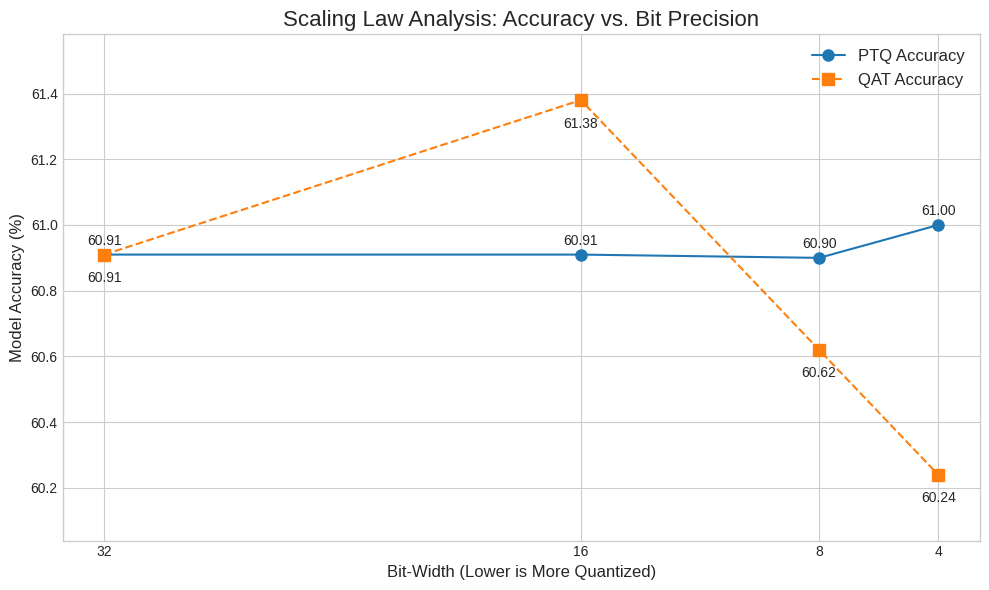

In [16]:
scaling_law(RESULTS_LIST)

In [10]:
# # ==============================================================================
# # Part 5: Mixed-Precision Quantization
# # ==============================================================================
def compute_activation_variance(model, dataloader, num_batches=50, device=DEVICE):
    """
    Compute activation variance for each layer.
    Layers with higher variance are typically more sensitive.
    """
    model.eval()
    layer_variances = {}
    activation_hooks = {}
    activations = {}
    
    def get_activation(name):
        def hook(module, input, output):
            if name not in activations:
                activations[name] = []
            activations[name].append(output.detach().cpu())
        return hook
    
    # Register hooks for conv and linear layers
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            activation_hooks[name] = module.register_forward_hook(get_activation(name))
    
    # Collect activations
    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            _ = model(inputs)
    
    # Remove hooks
    for hook in activation_hooks.values():
        hook.remove()
    
    # Compute variance for each layer
    for name, acts in activations.items():
        acts_tensor = torch.cat(acts, dim=0)
        variance = torch.var(acts_tensor).item()
        layer_variances[name] = variance
    
    return layer_variances

def get_conv_linear_layers(model):
    """Extract all Conv2d and Linear layers with their names"""
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append((name, module))
    return layers

In [11]:
def evaluate_quantized_model(quantized_cpu_model, test_loader):    
    quantized_cpu_model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(CPU_DEVICE, dtype=torch.float32)
            labels = labels.to(CPU_DEVICE)
            outputs = quantized_cpu_model(images)
            _, predictions = torch.max(outputs, 1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
    return 100.0 * total_correct / total_samples

In [12]:
import torch.ao.quantization as torch_ao_quant
CPU_DEVICE = torch.device("cpu")

In [18]:
fused_model = copy.deepcopy(fp32_model)
fused_model.eval()

# Define the exact fusion list for VGG-11
conv_relu_pairs = [
    [f'features.{i}', f'features.{i+1}'] for i in [0, 3, 6, 8, 11, 13, 16, 18]
]
linear_relu_pairs = [['classifier.0', 'classifier.1'], ['classifier.3', 'classifier.4']]

print("Fusing modules...")
torch.ao.quantization.fuse_modules(fused_model, conv_relu_pairs, inplace=True)
torch.ao.quantization.fuse_modules(fused_model, linear_relu_pairs, inplace=True)
print("Fusion complete.")

# --- Step 2: Define the QConfigMapping using the FUSED module names ---
# The names of the modules to keep in FP32 are the *first* part of the fused pair.
# The final classifier was not fused.
qconfig_int8 = get_default_qconfig('fbgemm')
qconfig_fp32 = None # Special value to skip quantization

qconfig_mapping = QConfigMapping() \
    .set_global(qconfig_int8) \
    .set_module_name('features.0', qconfig_fp32) \
    .set_module_name('classifier.6', qconfig_fp32)
    
print("\nConfiguration:")
print("Global: INT8")
print("FP32 Exceptions: 'features.0', 'classifier.6'")

# --- Step 3: Prepare the FUSED model with the mapping ---
# We must add Quant/DeQuant stubs to the start and end of the model
# because mixed-precision graphs require explicit boundaries.
fused_model.train() # Prepare needs train mode to insert observers
model_with_stubs = nn.Sequential(
    QuantStub(),
    fused_model,
    DeQuantStub()
)
prepared_model = torch.ao.quantization.prepare(model_with_stubs, qconfig_mapping)

# --- Step 4: Calibrate ---
print("Calibrating model...")
prepared_model.eval()
with torch.no_grad():
    for i, (images, _) in enumerate(tqdm(train_loader, desc="Calibrating")):
        if i > 8: break
        prepared_model(images)

# --- Step 5: Convert ---
print("Converting model...")
converted_model = torch.ao.quantization.convert(prepared_model)

# --- Step 6: Evaluate ---
print("\n--- Evaluating Final Mixed-Precision Model ---")
final_accuracy = evaluate_quantized_model(converted_model, test_loader)

print("\n--- FINAL RESULTS (QConfigMapping on Fused Model) ---")
print(f"Final Accuracy: {final_accuracy:.2f}%")

/usr/local/lib/python3.11/dist-packages/torch/ao/quantization/quantize.py:390: UserWarning: None of the submodule got qconfig applied. Make sure you passed correct configuration through `qconfig_dict` or by assigning the `.qconfig` attribute directly on submodules
  warnings.warn(


Fusing modules...
Fusion complete.

Configuration:
Global: INT8
FP32 Exceptions: 'features.0', 'classifier.6'
Calibrating model...


Calibrating:   5%|▍         | 9/196 [00:10<03:39,  1.17s/it]


Converting model...

--- Evaluating Final Mixed-Precision Model ---


Evaluating: 100%|██████████| 40/40 [00:41<00:00,  1.05s/it]


--- FINAL RESULTS (QConfigMapping on Fused Model) ---
Final Accuracy: 60.91%


In [19]:
size = get_model_size(converted_model)
latency = measure_inference_latency(converted_model, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'First/Last Layer FP32/INT8', 'Accuracy (%)': final_accuracy, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': DEVICE.type, 'Bits': 4, 'Method': 'Simple (First/Last) Mixed Precision'})
print(f"Simple Mixed-Precision -> Accuracy: {final_accuracy}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

Simple Mixed-Precision -> Accuracy: 60.91%, Size: 516.712996 MB, Latency: 2.0553327941894532 ms (cuda)


In [20]:
print("\n--- 3. Adaptive Mixed-Precision Quantization ---")

# First, compute sensitivities on the original FP32 model
print("Computing layer sensitivities...")
sensitivities = compute_activation_variance(fp32_model.to(DEVICE), train_loader, num_batches=50, device=DEVICE)

# Normalize sensitivities
max_sens = max(sensitivities.values())
normalized_sens = {k: v/max_sens for k, v in sensitivities.items()}

print("\nTop 10 Most Sensitive Layers:")
for name, sens in sorted(normalized_sens.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {name}: {sens:.4f}")

# Determine precision assignment
# Top 30% most sensitive -> FP32
# Bottom 70% -> INT8
threshold_high = np.percentile(list(normalized_sens.values()), 70)

precision_assignment = {}
for name, sens in normalized_sens.items():
    if sens >= threshold_high:
        precision_assignment[name] = 'fp32'
    else:
        precision_assignment[name] = 'int8'

fp_layers = sum(1 for p in precision_assignment.values() if p == 'fp32')
int8_layers = sum(1 for p in precision_assignment.values() if p == 'int8')

print(f"\nPrecision Assignment:")
print(f"  FP32 layers: {fp_layers}")
print(f"  INT8 layers: {int8_layers}")


--- 3. Adaptive Mixed-Precision Quantization ---
Computing layer sensitivities...

Top 10 Most Sensitive Layers:
  features.6: 1.0000
  classifier.6: 0.9584
  features.8: 0.8210
  features.3: 0.7344
  features.11: 0.6955
  features.13: 0.2876
  classifier.0: 0.1708
  classifier.3: 0.1493
  features.0: 0.1090
  features.16: 0.0908

Precision Assignment:
  FP32 layers: 4
  INT8 layers: 7


In [21]:
print("\n--- Applying Adaptive Mixed-Precision using QConfigMapping ---")

# --- Step 1: Load and Fuse the Model FIRST ---
fused_model = copy.deepcopy(fp32_model.cpu())
fused_model.eval()

# Define the exact fusion list for VGG-11
conv_relu_pairs = [
    [f'features.{i}', f'features.{i+1}'] for i in [0, 3, 6, 8, 11, 13, 16, 18]
]
linear_relu_pairs = [['classifier.0', 'classifier.1'], ['classifier.3', 'classifier.4']]

print("Fusing modules...")
torch.ao.quantization.fuse_modules(fused_model, conv_relu_pairs, inplace=True)
torch.ao.quantization.fuse_modules(fused_model, linear_relu_pairs, inplace=True)
print("Fusion complete.")

# --- Step 2: Define the ADAPTIVE QConfigMapping based on your results ---
# Based on your analysis, the top 4 most sensitive layers will be kept in FP32.
# The names refer to the *original* module name, which is the name of the
# new fused module (e.g., 'features.6' now refers to the ConvReLU2d module).
fp32_layer_names = {
    'features.6',
    'classifier.6',
    'features.8',
    'features.3',
}

qconfig_int8 = get_default_qconfig('fbgemm')
qconfig_fp32 = None # Special value to skip quantization

# Start with a global INT8 config
adaptive_qconfig_mapping = QConfigMapping().set_global(qconfig_int8)

# Programmatically set the sensitive layers to be skipped (kept in FP32)
print("\nAdaptive Configuration:")
print("  Global: INT8")
print("  FP32 Exceptions (most sensitive layers):")
for layer_name in fp32_layer_names:
    adaptive_qconfig_mapping.set_module_name(layer_name, qconfig_fp32)
    print(f"    - {layer_name}")

# --- Step 3: Prepare the FUSED model with the adaptive mapping ---
# Wrap the entire fused model in Quant/DeQuant stubs. This is essential for
# any graph that contains mixed precision.
fused_model.train() # Prepare needs train mode to insert observers
model_with_stubs = nn.Sequential(
    QuantStub(),
    fused_model,
    DeQuantStub()
)
prepared_model = torch.ao.quantization.prepare(model_with_stubs, adaptive_qconfig_mapping)

# --- Step 4: Calibrate ---
print("\nCalibrating model...")
prepared_model.eval()
with torch.no_grad():
    for i, (images, _) in enumerate(tqdm(train_loader, desc="Calibrating")):
        if i > 8: break # Use a small but representative sample
        prepared_model(images)

# --- Step 5: Convert ---
print("Converting model...")
converted_model = torch.ao.quantization.convert(prepared_model)

# --- Step 6: Evaluate ---
print("\n--- Evaluating Final Adaptive Mixed-Precision Model ---")
final_accuracy = evaluate_quantized_model(converted_model, test_loader)

print("\n--- FINAL ADAPTIVE RESULTS ---")
print(f"Final Accuracy: {final_accuracy:.2f}%")


--- Applying Adaptive Mixed-Precision using QConfigMapping ---
Fusing modules...
Fusion complete.

Adaptive Configuration:
  Global: INT8
  FP32 Exceptions (most sensitive layers):
    - classifier.6
    - features.6
    - features.8
    - features.3

Calibrating model...


Calibrating:   5%|▍         | 9/196 [00:10<03:39,  1.17s/it]


Converting model...

--- Evaluating Final Adaptive Mixed-Precision Model ---


Evaluating: 100%|██████████| 40/40 [00:42<00:00,  1.06s/it]


--- FINAL ADAPTIVE RESULTS ---
Final Accuracy: 60.91%


In [22]:
size = get_model_size(converted_model)
latency = measure_inference_latency(converted_model, DEVICE, (torch.randn(1, 3, 32, 32, device=DEVICE.type),))
# RESULTS_LIST.append({'Model': 'Adaptive FP32/INT8', 'Accuracy (%)': final_accuracy, 'Size (MB)': size, 'Latency (ms)': latency, 'Device': "cpu", 'Bits': '8/32', 'Method': 'Adaptive (Activation Variance) Mixed Precision'})
print(f"Simple Mixed-Precision -> Accuracy: {final_accuracy}%, Size: {size} MB, Latency: {latency} ms ({DEVICE.type})")

Simple Mixed-Precision -> Accuracy: 60.91%, Size: 516.712996 MB, Latency: 1.9863363647460937 ms (cuda)


In [23]:
display_results(RESULTS_LIST)

Model Performance Comparison


,Model,Method,Bits,Accuracy (%),Latency (ms),Size (MB),Device
0,FP32 Baseline,None,32,60.91,2.415,516.712,cuda
1,PTQ-FP16,PTQ,16,60.91,2.142,258.360,cuda
2,PTQ-INT8,PTQ,8,60.90,3.719,156.973,cuda
3,PTQ-INT4,PTQ,4,61.00,0.232,104.424,cpu
4,PTQ-BF16,PTQ,8,60.90,4.084,258.360,cuda
5,QAT-FP16,QAT,16,60.53,1.915,258.360,cuda
6,QAT-BF16,QAT,16,61.38,3.795,258.360,cuda
7,QAT-INT8,QAT,8,60.62,1.921,516.712,cuda
8,QAT-INT4,QAT,4,60.24,1.925,516.712,cuda
9,First/Last Layer FP32/INT8,Simple (First/Last) Mixed Precision,8/32,60.91,2.009,516.713,cpu



Inferred Metrics and Analysis

1. Model Size Reduction vs. Baseline (FP32):


,Model,Size (MB),Size Reduction (%)
0,FP32 Baseline,516.712,0.00
1,PTQ-FP16,258.360,50.00
2,PTQ-INT8,156.973,69.62
3,PTQ-INT4,104.424,79.79
4,PTQ-BF16,258.360,50.00
5,QAT-FP16,258.360,50.00
6,QAT-BF16,258.360,50.00
7,QAT-INT8,516.712,0.00
8,QAT-INT4,516.712,0.00
9,First/Last Layer FP32/INT8,516.713,-0.00



2. Accuracy per Megabyte (Efficiency):


,Model,Accuracy per MB
0,FP32 Baseline,0.12
1,PTQ-FP16,0.24
2,PTQ-INT8,0.39
3,PTQ-INT4,0.58
4,PTQ-BF16,0.24
5,QAT-FP16,0.23
6,QAT-BF16,0.24
7,QAT-INT8,0.12
8,QAT-INT4,0.12
9,First/Last Layer FP32/INT8,0.12



3. Latency Change vs. Baseline (CUDA devices only):


,Model,Device,Latency (ms),Latency Change vs Baseline (%)
0,FP32 Baseline,cuda,2.415,0.0
1,PTQ-FP16,cuda,2.142,-11.3
2,PTQ-INT8,cuda,3.719,54.0
3,PTQ-INT4,cpu,0.232,N/A (CPU)
4,PTQ-BF16,cuda,4.084,69.11
5,QAT-FP16,cuda,1.915,-20.7
6,QAT-BF16,cuda,3.795,57.14
7,QAT-INT8,cuda,1.921,-20.46
8,QAT-INT4,cuda,1.925,-20.29
9,First/Last Layer FP32/INT8,cpu,2.009,N/A (CPU)


In [ ]:
# with open('PTQ-QAT-MP_RESULTS.pkl', 'wb') as p:
#     pickle.dump(RESULTS_LIST, p)

In [6]:
class ActivationCollector:
    """Collect and analyze activations from model layers"""
    
    def __init__(self, model):
        self.model = model
        self.activations = defaultdict(list)
        self.hooks = []
        
    def register_hooks(self):
        """Register forward hooks to collect activations"""
        def get_activation(name):
            def hook(module, input, output):
                # Store a sample of activations to avoid memory issues
                self.activations[name].append(output.detach().cpu())
            return hook
        
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear, nn.ReLU)):
                hook = module.register_forward_hook(get_activation(name))
                self.hooks.append(hook)
    
    def remove_hooks(self):
        """Remove all hooks"""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
    
    def collect_activations(self, dataloader, num_batches=50):
        """Collect activations from dataloader"""
        self.model.eval()
        self.register_hooks()
        
        with torch.no_grad():
            for i, (inputs, _) in enumerate(dataloader):
                if i >= num_batches:
                    break
                inputs = inputs.to(DEVICE)
                _ = self.model(inputs)
        
        self.remove_hooks()
        
        # Concatenate collected activations
        for name in self.activations:
            self.activations[name] = torch.cat(self.activations[name], dim=0)
    
    def analyze_outliers(self, layer_name):
        """Analyze outliers in a specific layer"""
        if layer_name not in self.activations:
            return None
        
        acts = self.activations[layer_name].flatten().numpy()
        
        stats_dict = {
            'mean': np.mean(acts),
            'std': np.std(acts),
            'min': np.min(acts),
            'max': np.max(acts),
            'median': np.median(acts),
            'q1': np.percentile(acts, 25),
            'q3': np.percentile(acts, 75),
            'p95': np.percentile(acts, 95),
            'p99': np.percentile(acts, 99),
            'p99.9': np.percentile(acts, 99.9),
            'iqr': np.percentile(acts, 75) - np.percentile(acts, 25),
        }
        
        # Outlier detection using IQR method
        iqr = stats_dict['iqr']
        lower_bound = stats_dict['q1'] - 1.5 * iqr
        upper_bound = stats_dict['q3'] + 1.5 * iqr
        outliers = (acts < lower_bound) | (acts > upper_bound)
        stats_dict['outlier_ratio'] = np.mean(outliers)
        
        # Dynamic range
        stats_dict['dynamic_range'] = stats_dict['max'] - stats_dict['min']
        
        # Kurtosis (tail heaviness)
        stats_dict['kurtosis'] = stats.kurtosis(acts)
        
        return stats_dict, acts
    
    def get_layer_names(self):
        """Get all collected layer names"""
        return list(self.activations.keys())

# ============================================================================
# Weight Analysis
# ============================================================================

def analyze_weight_outliers(model):
    """Analyze outliers in model weights"""
    weight_stats = {}
    
    for name, param in model.named_parameters():
        if 'weight' in name and param.dim() > 1:
            weights = param.detach().cpu().numpy().flatten()
            
            stats_dict = {
                'mean': np.mean(weights),
                'std': np.std(weights),
                'min': np.min(weights),
                'max': np.max(weights),
                'p99.9': np.percentile(weights, 99.9),
                'p0.1': np.percentile(weights, 0.1),
                'dynamic_range': np.max(weights) - np.min(weights),
                'kurtosis': stats.kurtosis(weights)
            }
            
            weight_stats[name] = (stats_dict, weights)
    
    return weight_stats

In [25]:
# ============================================================================
# Quantization Strategies
# ============================================================================

class UniformQuantizer:
    """Standard uniform quantization without clipping"""
    
    def __init__(self, n_bits=8):
        self.n_bits = n_bits
        self.n_levels = 2 ** n_bits
        
    def quantize(self, x):
        """Quantize tensor x"""
        x_min = x.min()
        x_max = x.max()
        
        # Compute scale and zero point
        scale = (x_max - x_min) / (self.n_levels - 1)
        zero_point = -x_min / scale
        
        # Quantize
        x_q = torch.clamp(torch.round(x / scale + zero_point), 0, self.n_levels - 1)
        
        # Dequantize
        x_dq = (x_q - zero_point) * scale
        
        return x_dq, scale, zero_point
    
    def quantization_error(self, x):
        """Compute quantization error"""
        x_dq, _, _ = self.quantize(x)
        error = torch.abs(x - x_dq)
        return error.mean().item(), error.max().item()

class ClippedQuantizer:
    """Quantization with percentile-based clipping"""
    
    def __init__(self, n_bits=8, clip_percentile=99.9, use_sampling=True, max_samples=1000000):
        self.n_bits = n_bits
        self.n_levels = 2 ** n_bits
        self.clip_percentile = clip_percentile
        self.use_sampling = use_sampling
        self.max_samples = max_samples
        
    def quantize(self, x):
        # """Quantize with clipping"""
        # # Compute clipping bounds
        # x_flat = x.flatten()
        # lower_percentile = (100 - self.clip_percentile) / 2
        # upper_percentile = 100 - lower_percentile
        
        # x_min = torch.quantile(x_flat, lower_percentile / 100)
        # x_max = torch.quantile(x_flat, upper_percentile / 100)
        
        # # Clip values
        # x_clipped = torch.clamp(x, x_min, x_max)
        
        # # Compute scale and zero point
        # scale = (x_max - x_min) / (self.n_levels - 1)
        # zero_point = -x_min / scale
        
        # # Quantize
        # x_q = torch.clamp(torch.round(x_clipped / scale + zero_point), 0, self.n_levels - 1)
        
        # # Dequantize
        # x_dq = (x_q - zero_point) * scale
        
        # return x_dq, scale, zero_point

        """Quantize with clipping"""
        # Compute clipping bounds
        x_flat = x.flatten()
        
        # For very large tensors, use sampling
        if self.use_sampling and x_flat.numel() > self.max_samples:
            # Randomly sample for percentile estimation
            indices = torch.randperm(x_flat.numel())[:self.max_samples]
            x_sample = x_flat[indices].cpu().numpy()
        else:
            x_sample = x_flat.cpu().numpy()
        
        lower_percentile = (100 - self.clip_percentile) / 2
        upper_percentile = 100 - lower_percentile
        
        # Use numpy for percentile calculation (more memory efficient)
        x_min = torch.tensor(np.percentile(x_sample, lower_percentile), device=x.device, dtype=x.dtype)
        x_max = torch.tensor(np.percentile(x_sample, upper_percentile), device=x.device, dtype=x.dtype)
        
        # Clip values
        x_clipped = torch.clamp(x, x_min, x_max)
        
        # Compute scale and zero point
        scale = (x_max - x_min) / (self.n_levels - 1)
        zero_point = -x_min / scale
        
        # Quantize
        x_q = torch.clamp(torch.round(x_clipped / scale + zero_point), 0, self.n_levels - 1)
        
        # Dequantize
        x_dq = (x_q - zero_point) * scale
        
        return x_dq, scale, zero_point
    
    def quantization_error(self, x):
        """Compute quantization error"""
        x_dq, _, _ = self.quantize(x)
        error = torch.abs(x - x_dq)
        return error.mean().item(), error.max().item()

class LogQuantizer:
    """Logarithmic quantization for heavy-tailed distributions"""
    
    def __init__(self, n_bits=8, epsilon=1e-7):
        self.n_bits = n_bits
        self.n_levels = 2 ** n_bits
        self.epsilon = epsilon
        
    def quantize(self, x):
        # """Quantize using log scale"""
        # # Handle sign
        # sign = torch.sign(x)
        # x_abs = torch.abs(x)
        
        # # Add small epsilon to avoid log(0)
        # epsilon = 1e-7
        # x_log = torch.log(x_abs + epsilon)
        
        # # Quantize in log space
        # log_min = x_log.min()
        # log_max = x_log.max()
        
        # scale = (log_max - log_min) / (self.n_levels - 1)
        # zero_point = -log_min / scale
        
        # x_q = torch.clamp(torch.round(x_log / scale + zero_point), 0, self.n_levels - 1)
        
        # # Dequantize back to linear space
        # x_log_dq = (x_q - zero_point) * scale
        # x_dq = sign * (torch.exp(x_log_dq) - epsilon)
        
        # return x_dq, scale, zero_point

        """Quantize using log scale"""
        # Handle sign
        sign = torch.sign(x)
        x_abs = torch.abs(x)
        
        # Add small epsilon to avoid log(0)
        x_log = torch.log(x_abs + self.epsilon)
        
        # Quantize in log space
        log_min = x_log.min()
        log_max = x_log.max()
        
        # Handle edge case where all values are the same
        if torch.isclose(log_min, log_max):
            return x.clone(), torch.tensor(1.0), torch.tensor(0.0)
        
        scale = (log_max - log_min) / (self.n_levels - 1)
        zero_point = -log_min / scale
        
        x_q = torch.clamp(torch.round(x_log / scale + zero_point), 0, self.n_levels - 1)
        
        # Dequantize back to linear space
        x_log_dq = (x_q - zero_point) * scale
        x_dq = sign * (torch.exp(x_log_dq) - self.epsilon)
        
        return x_dq, scale, zero_point
    
    def quantization_error(self, x):
        """Compute quantization error"""
        x_dq, _, _ = self.quantize(x)
        error = torch.abs(x - x_dq)
        return error.mean().item(), error.max().item()

In [8]:
# ============================================================================
# Quantized Model with Different Strategies
# ============================================================================

def apply_quantization_strategy(model, strategy='uniform', n_bits=8, clip_percentile=99.9):
    """
    Apply quantization strategy to model weights
    
    Args:
        strategy: 'uniform', 'clipped', or 'log'
        n_bits: number of bits for quantization
        clip_percentile: percentile for clipping (if applicable)
    """
    model_copy = copy.deepcopy(model)
    
    if strategy == 'uniform':
        quantizer = UniformQuantizer(n_bits=n_bits)
    elif strategy == 'clipped':
        quantizer = ClippedQuantizer(n_bits=n_bits, clip_percentile=clip_percentile)
    elif strategy == 'log':
        quantizer = LogQuantizer(n_bits=n_bits)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    # Quantize weights
    quantization_errors = {}
    with torch.no_grad():
        for name, param in model_copy.named_parameters():
            if 'weight' in name and param.dim() > 1:
                original = param.data
                quantized, _, _ = quantizer.quantize(original)
                param.data = quantized
                
                # Track error
                mean_err, max_err = quantizer.quantization_error(original)
                quantization_errors[name] = {'mean': mean_err, 'max': max_err}
    
    return model_copy, quantization_errors

In [14]:
# ============================================================================
# Visualization Functions
# ============================================================================

def plot_activation_distributions(collector, layer_names=None, num_layers=6):
    """Plot activation distributions for selected layers"""
    if layer_names is None:
        # Select diverse layers
        all_layers = collector.get_layer_names()
        conv_layers = [n for n in all_layers if 'features' in n and 'Conv2d' not in n]
        layer_names = conv_layers[::len(conv_layers)//num_layers][:num_layers]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, layer_name in enumerate(layer_names):
        if idx >= len(axes):
            break
            
        stats_dict, acts = collector.analyze_outliers(layer_name)
        
        ax = axes[idx]
        
        # Histogram
        ax.hist(acts, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
        
        # Mark percentiles
        p99 = stats_dict['p99']
        p999 = stats_dict['p99.9']
        
        ax.axvline(p99, color='orange', linestyle='--', linewidth=2, label='99th percentile')
        ax.axvline(p999, color='red', linestyle='--', linewidth=2, label='99.9th percentile')
        
        ax.set_xlabel('Activation Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{layer_name}\nOutliers: {stats_dict["outlier_ratio"]*100:.2f}%', fontsize=11)
        ax.legend(fontsize=8)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('activation_distributions.png', dpi=300, bbox_inches='tight')
    print("Saved: activation_distributions.png")
    plt.close()

def plot_outlier_boxplots(collector, layer_names=None):
    """Create box plots showing outliers across layers"""
    if layer_names is None:
        all_layers = collector.get_layer_names()
        conv_layers = [n for n in all_layers if 'features' in n and 'Conv2d' not in n]
        layer_names = conv_layers[::2]  # Every other layer
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    data_to_plot = []
    labels = []
    
    for layer_name in layer_names:
        _, acts = collector.analyze_outliers(layer_name)
        # Sample for visualization
        sampled = np.random.choice(acts, size=min(10000, len(acts)), replace=False)
        data_to_plot.append(sampled)
        labels.append(layer_name.split('.')[-1] if '.' in layer_name else layer_name)
    
    bp = ax.boxplot(data_to_plot, labels=labels, showfliers=True, 
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('Activation Value', fontsize=12)
    ax.set_title('Activation Distribution Across Layers (Box Plots)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('activation_boxplots.png', dpi=300, bbox_inches='tight')
    print("Saved: activation_boxplots.png")
    plt.show()
    # plt.close()

def plot_weight_distributions(weight_stats, num_layers=6):
    """Plot weight distributions"""
    layer_names = list(weight_stats.keys())[:num_layers]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, layer_name in enumerate(layer_names):
        if idx >= len(axes):
            break
        
        stats_dict, weights = weight_stats[layer_name]
        
        ax = axes[idx]
        ax.hist(weights, bins=100, alpha=0.7, color='coral', edgecolor='black')
        
        # Mark percentiles
        p999 = stats_dict['p99.9']
        p001 = stats_dict['p0.1']
        
        ax.axvline(p999, color='red', linestyle='--', linewidth=2, label='99.9th percentile')
        ax.axvline(p001, color='red', linestyle='--', linewidth=2, label='0.1th percentile')
        
        short_name = layer_name.split('.')[-2] if '.' in layer_name else layer_name
        ax.set_xlabel('Weight Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{short_name}\nKurtosis: {stats_dict["kurtosis"]:.2f}', fontsize=11)
        ax.legend(fontsize=8)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('weight_distributions.png', dpi=300, bbox_inches='tight')
    print("Saved: weight_distributions.png")
    plt.show()
    # plt.close()

def plot_quantization_comparison(original_acts, uniform_acts, clipped_acts, log_acts, layer_name):
    """Compare quantization strategies on same activation distribution"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    strategies = [
        ('Original', original_acts, 'steelblue'),
        ('Uniform Quant', uniform_acts, 'orange'),
        ('Clipped Quant', clipped_acts, 'green'),
        ('Log Quant', log_acts, 'red')
    ]
    
    for idx, (title, acts, color) in enumerate(strategies):
        ax = axes[idx // 2, idx % 2]
        
        ax.hist(acts.flatten().numpy(), bins=100, alpha=0.7, color=color, edgecolor='black')
        ax.set_xlabel('Activation Value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{title}\nRange: [{acts.min():.3f}, {acts.max():.3f}]', fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Quantization Strategy Comparison - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'quantization_comparison_{layer_name}.png', dpi=300, bbox_inches='tight')
    print(f"Saved: quantization_comparison_{layer_name}.png")
    plt.show()
    # plt.close()

def plot_layer_wise_error(quantization_errors_dict):
    """Plot quantization errors across layers for different strategies"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    strategies = list(quantization_errors_dict.keys())
    layer_names = list(next(iter(quantization_errors_dict.values())).keys())
    
    # Mean errors
    x = np.arange(len(layer_names))
    width = 0.25
    
    for i, strategy in enumerate(strategies):
        errors = quantization_errors_dict[strategy]
        mean_errors = [errors[ln]['mean'] for ln in layer_names]
        ax1.bar(x + i*width, mean_errors, width, label=strategy, alpha=0.8)
    
    ax1.set_xlabel('Layer', fontsize=12)
    ax1.set_ylabel('Mean Quantization Error', fontsize=12)
    ax1.set_title('Mean Quantization Error by Layer', fontsize=13, fontweight='bold')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels([ln.split('.')[-2] for ln in layer_names], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Max errors
    for i, strategy in enumerate(strategies):
        errors = quantization_errors_dict[strategy]
        max_errors = [errors[ln]['max'] for ln in layer_names]
        ax2.bar(x + i*width, max_errors, width, label=strategy, alpha=0.8)
    
    ax2.set_xlabel('Layer', fontsize=12)
    ax2.set_ylabel('Max Quantization Error', fontsize=12)
    ax2.set_title('Maximum Quantization Error by Layer', fontsize=13, fontweight='bold')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels([ln.split('.')[-2] for ln in layer_names], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('layerwise_quantization_error.png', dpi=300, bbox_inches='tight')
    print("Saved: layerwise_quantization_error.png")
    plt.show()
    # plt.close()

In [10]:
# ============================================================================
# Main Experiment
# ============================================================================

"""Run complete outlier analysis experiment"""

print("="*80)
print("OUTLIER ANALYSIS IN QUANTIZATION")
print("="*80)

# Load or train model
print("\nLoading/Training VGG-11 model...")
model = copy.deepcopy(fp32_model.to(DEVICE))

# For demonstration, assume model is trained
# In practice: model = train_model(model, trainloader, epochs=100)
# print("Note: Using initialized model for demonstration. Train for ~100 epochs for real results.")

# Evaluate baseline
baseline_acc = evaluate_model(model, test_loader)
print(f"\nBaseline FP32 Accuracy: {baseline_acc:.2f}%")

OUTLIER ANALYSIS IN QUANTIZATION

Loading/Training VGG-11 model...

Baseline FP32 Accuracy: 60.91%



PART 1: Activation Outlier Analysis


Generating activation distribution plots...
Saved: activation_distributions.png
Saved: activation_boxplots.png


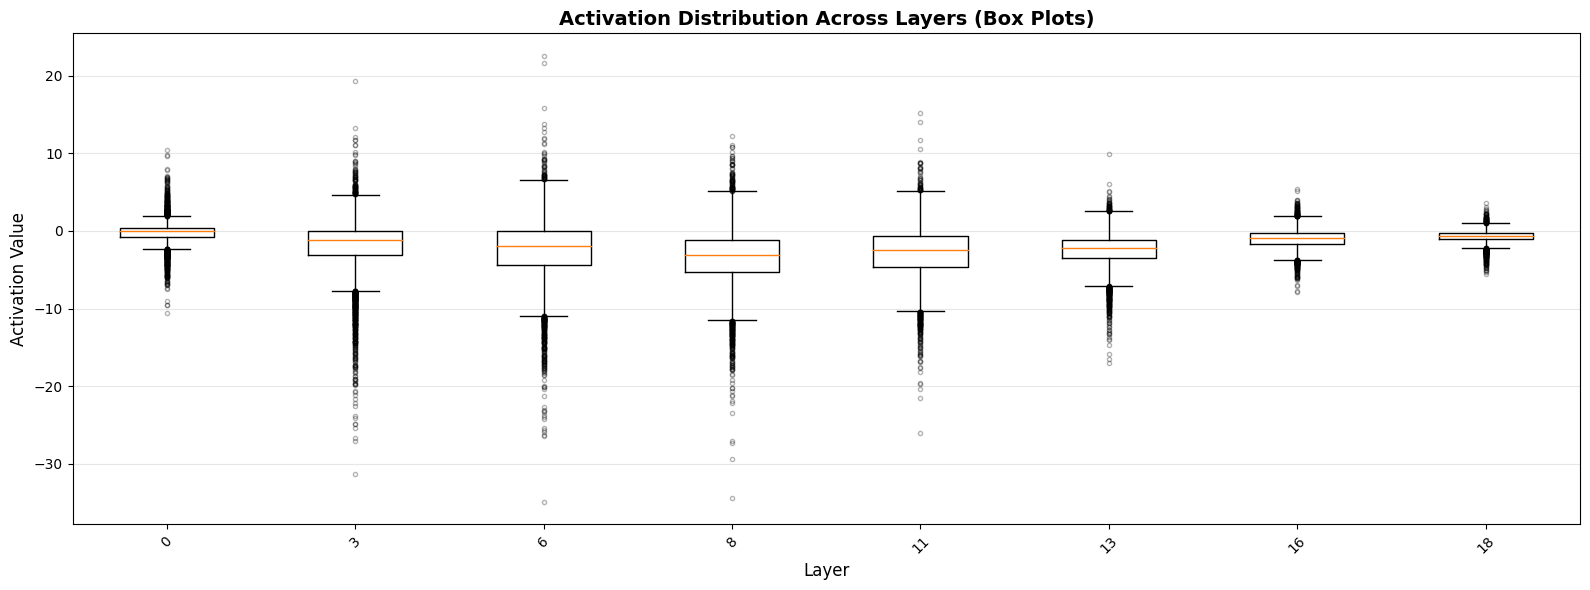


Activation Statistics for Selected Layers:
--------------------------------------------------------------------------------

features.0:
  Mean: -0.2078, Std: 1.2892
  Range: [-19.6984, 18.1061]
  Dynamic Range: 37.8045
  99.9th percentile: 6.5731
  Outlier Ratio: 7.98%
  Kurtosis: 6.14

features.4:
  Mean: 0.3583, Std: 0.9765
  Range: [0.0000, 37.6262]
  Dynamic Range: 37.6262
  99.9th percentile: 8.9883
  Outlier Ratio: 23.65%
  Kurtosis: 32.94

features.8:
  Mean: -3.3148, Std: 3.5338
  Range: [-61.5092, 44.2597]
  Dynamic Range: 105.7689
  99.9th percentile: 9.4973
  Outlier Ratio: 3.17%
  Kurtosis: 2.47

features.12:
  Mean: 0.2840, Std: 0.9025
  Range: [0.0000, 31.6618]
  Dynamic Range: 31.6618
  99.9th percentile: 8.3366
  Outlier Ratio: 17.71%
  Kurtosis: 37.34

features.16:
  Mean: -0.9219, Std: 1.1791
  Range: [-12.7359, 10.9384]
  Dynamic Range: 23.6743
  99.9th percentile: 3.4944
  Outlier Ratio: 2.66%
  Kurtosis: 1.66


In [15]:
# ========================================================================
# PART 1: Analyze Activation Outliers
# ========================================================================
print("\n" + "="*80)
print("PART 1: Activation Outlier Analysis")
print("="*80)

collector = ActivationCollector(model)
print("\nCollecting activations...")
collector.collect_activations(train_loader, num_batches=10)

# Analyze and visualize
print("\nGenerating activation distribution plots...")
plot_activation_distributions(collector)
plot_outlier_boxplots(collector)

# Print statistics for key layers
key_layers = [n for n in collector.get_layer_names() if 'features' in n][::3][:5]
print("\nActivation Statistics for Selected Layers:")
print("-" * 80)
for layer_name in key_layers:
    stats_dict, _ = collector.analyze_outliers(layer_name)
    print(f"\n{layer_name}:")
    print(f"  Mean: {stats_dict['mean']:.4f}, Std: {stats_dict['std']:.4f}")
    print(f"  Range: [{stats_dict['min']:.4f}, {stats_dict['max']:.4f}]")
    print(f"  Dynamic Range: {stats_dict['dynamic_range']:.4f}")
    print(f"  99.9th percentile: {stats_dict['p99.9']:.4f}")
    print(f"  Outlier Ratio: {stats_dict['outlier_ratio']*100:.2f}%")
    print(f"  Kurtosis: {stats_dict['kurtosis']:.2f}")


PART 2: Weight Outlier Analysis
Saved: weight_distributions.png


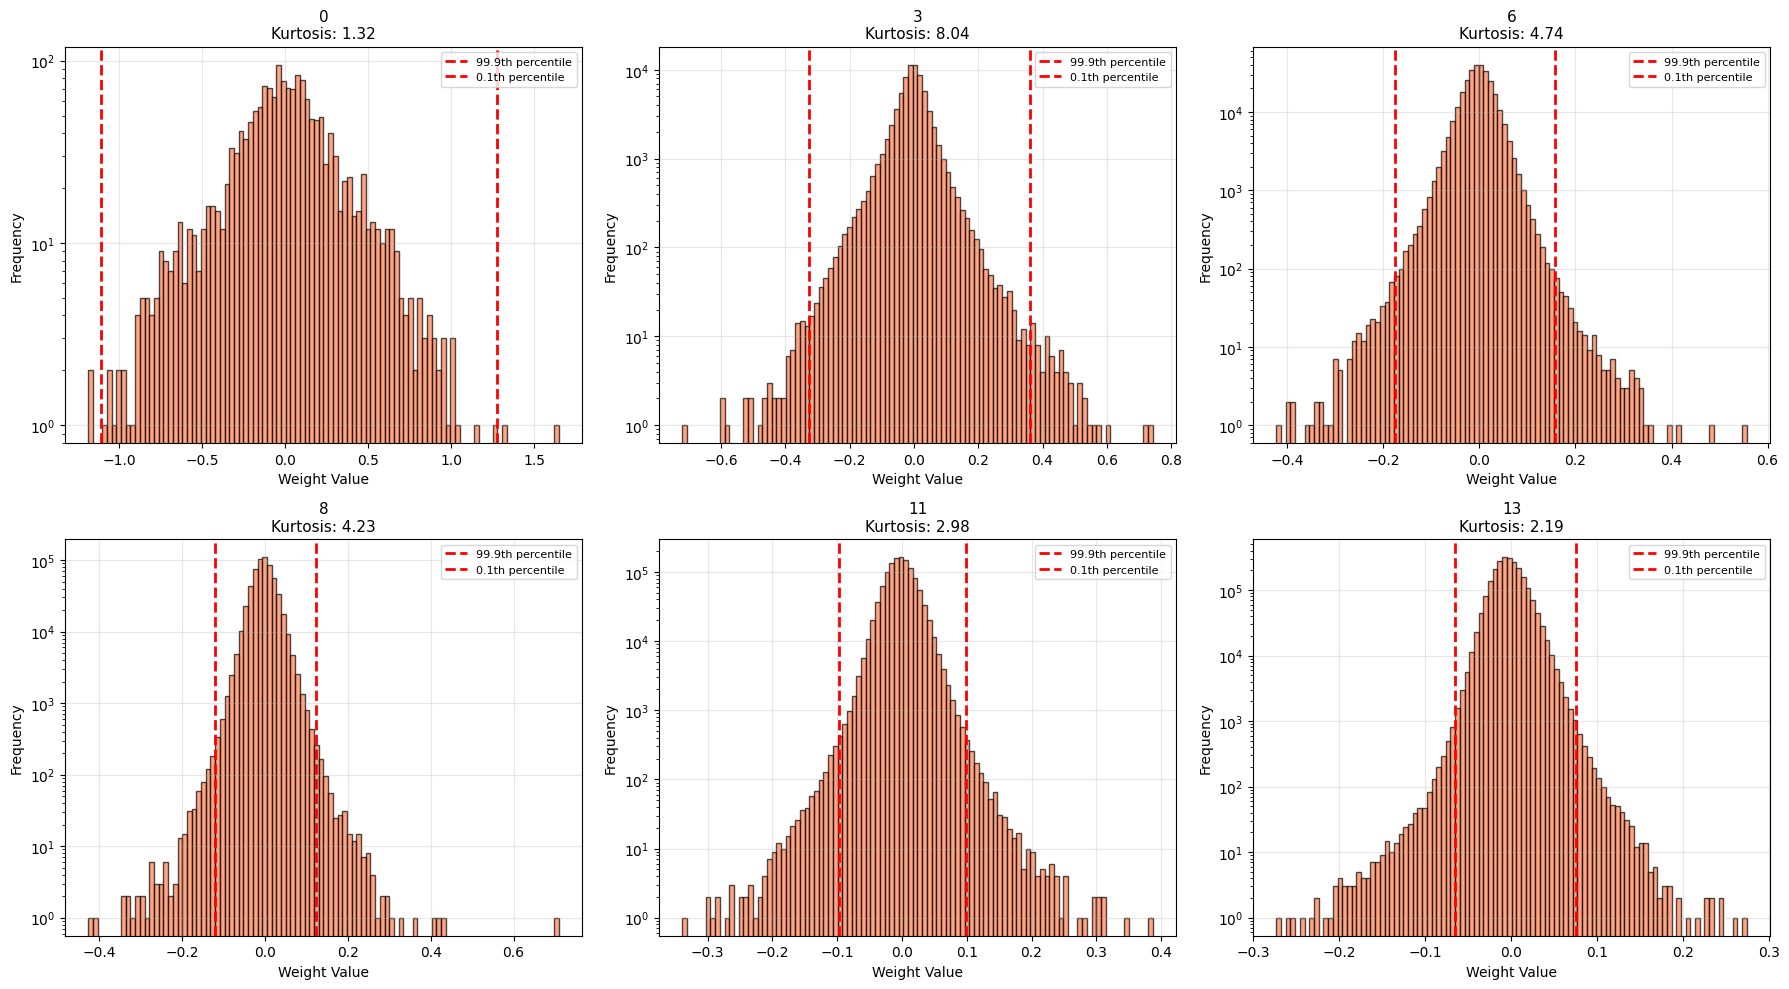

In [16]:
# ========================================================================
# PART 2: Analyze Weight Outliers
# ========================================================================
print("\n" + "="*80)
print("PART 2: Weight Outlier Analysis")
print("="*80)

weight_stats = analyze_weight_outliers(model)
plot_weight_distributions(weight_stats)

In [26]:
# ========================================================================
# PART 3: Compare Quantization Strategies
# ========================================================================
print("\n" + "="*80)
print("PART 3: Quantization Strategy Comparison")
print("="*80)

results = []
quantization_errors_dict = {}

# Test different strategies and bit-widths
strategies = [
    ('uniform', 8, None),
    ('clipped', 8, 99.9),
    ('clipped', 8, 99.0),
    ('log', 8, None),
    ('uniform', 4, None),
    ('clipped', 4, 99.9),
]

for strategy, n_bits, clip_percentile in strategies:
    strategy_name = f"{strategy.capitalize()}-{n_bits}bit"
    if clip_percentile:
        strategy_name += f"-{clip_percentile}%"
    
    print(f"\nTesting: {strategy_name}")
    
    # Apply quantization
    quantized_model, quant_errors = apply_quantization_strategy(
        model, strategy=strategy, n_bits=n_bits, 
        clip_percentile=clip_percentile if clip_percentile else 99.9
    )
    
    # Evaluate
    acc = evaluate_model(quantized_model, test_loader)
    
    # Calculate average errors
    avg_mean_error = np.mean([e['mean'] for e in quant_errors.values()])
    avg_max_error = np.mean([e['max'] for e in quant_errors.values()])
    
    print(f"  Accuracy: {acc:.2f}% (Δ: {acc - baseline_acc:+.2f}%)")
    print(f"  Avg Mean Error: {avg_mean_error:.6f}")
    print(f"  Avg Max Error: {avg_max_error:.6f}")
    
    results.append({
        'Strategy': strategy_name,
        'Bits': n_bits,
        'Accuracy': acc,
        'Acc_Delta': acc - baseline_acc,
        'Avg_Mean_Error': avg_mean_error,
        'Avg_Max_Error': avg_max_error
    })
    
    quantization_errors_dict[strategy_name] = quant_errors


PART 3: Quantization Strategy Comparison

Testing: Uniform-8bit
  Accuracy: 60.83% (Δ: -0.08%)
  Avg Mean Error: 0.000797
  Avg Max Error: 0.001594

Testing: Clipped-8bit-99.9%
  Accuracy: 59.46% (Δ: -1.45%)
  Avg Mean Error: 0.000471
  Avg Max Error: 0.228119

Testing: Clipped-8bit-99.0%
  Accuracy: 44.72% (Δ: -16.19%)
  Avg Mean Error: 0.000611
  Avg Max Error: 0.305789

Testing: Log-8bit
  Accuracy: 60.78% (Δ: -0.13%)
  Avg Mean Error: 0.000458
  Avg Max Error: 0.008097

Testing: Uniform-4bit
  Accuracy: 36.90% (Δ: -24.01%)
  Avg Mean Error: 0.013969
  Avg Max Error: 0.027106

Testing: Clipped-4bit-99.9%
  Accuracy: 56.43% (Δ: -4.48%)
  Avg Mean Error: 0.007513
  Avg Max Error: 0.228079



PART 4: Visualizing Quantization Effects
Saved: quantization_comparison_features.8.png


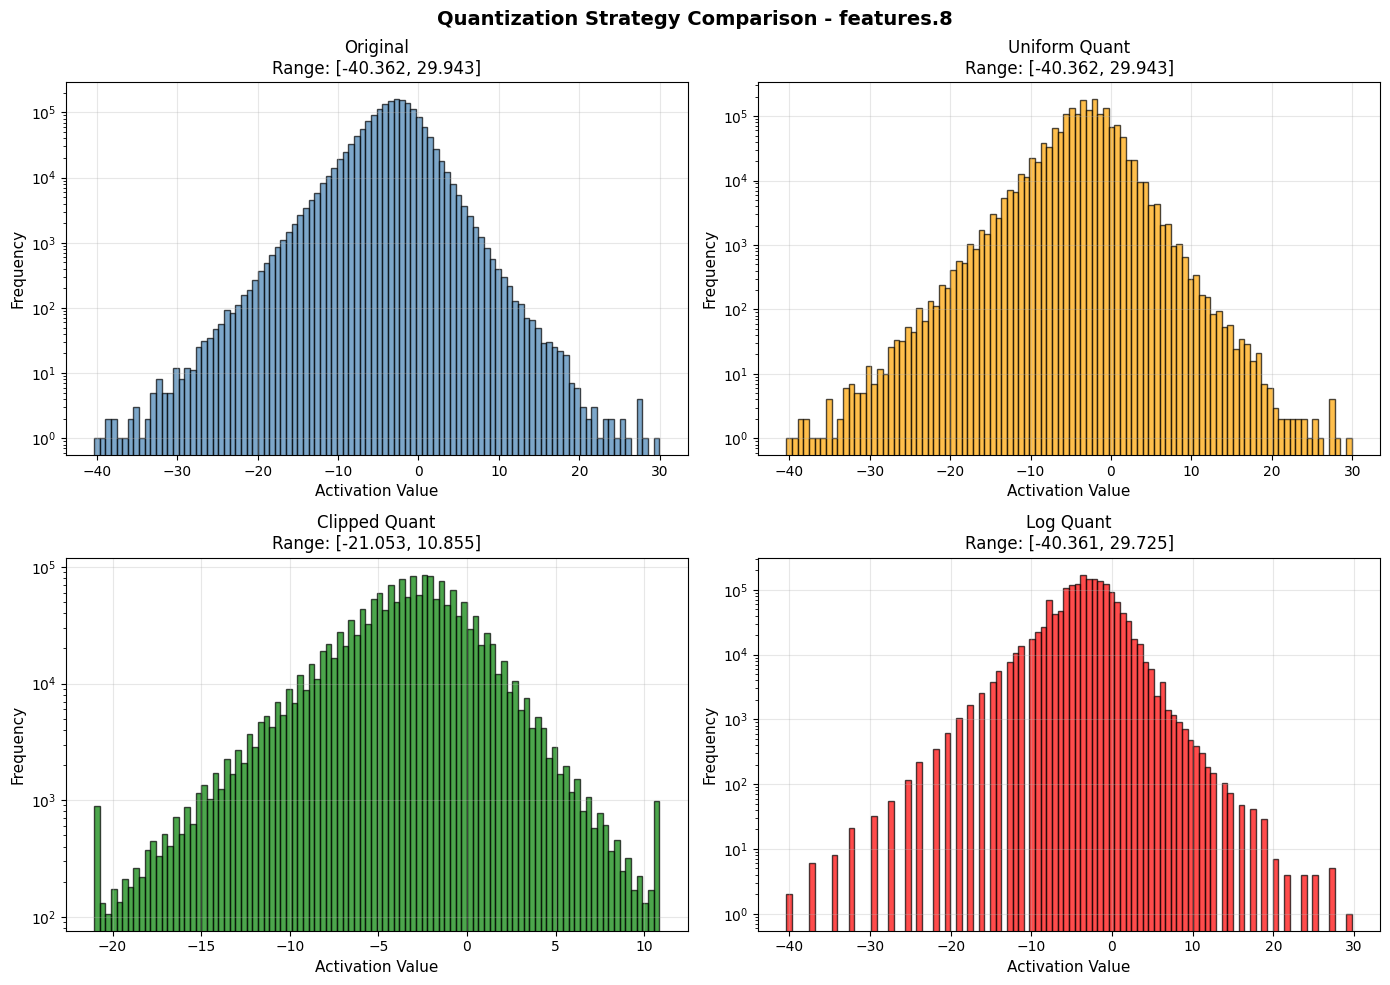

Saved: layerwise_quantization_error.png


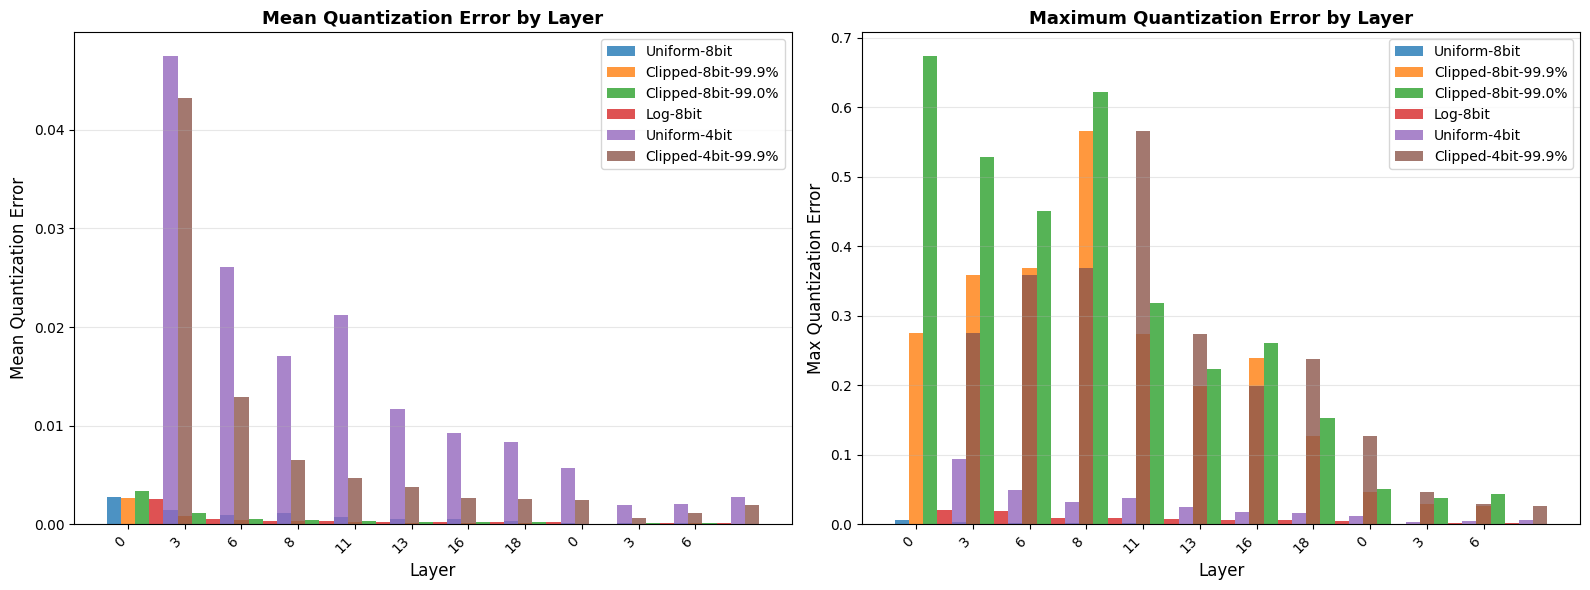

In [27]:
# ========================================================================
# PART 4: Visualize Quantization Effects
# ========================================================================
print("\n" + "="*80)
print("PART 4: Visualizing Quantization Effects")
print("="*80)

# Pick a representative layer
test_layer = key_layers[2]  # Middle layer
if test_layer in collector.activations:
    original = collector.activations[test_layer][:100]  # Sample
    
    # Apply different quantizers
    uniform_q = UniformQuantizer(n_bits=8)
    clipped_q = ClippedQuantizer(n_bits=8, clip_percentile=99.9)
    log_q = LogQuantizer(n_bits=8)
    
    uniform_acts, _, _ = uniform_q.quantize(original)
    clipped_acts, _, _ = clipped_q.quantize(original)
    log_acts, _, _ = log_q.quantize(original)
    
    plot_quantization_comparison(original, uniform_acts, clipped_acts, log_acts, test_layer)

# Plot layer-wise errors
plot_layer_wise_error(quantization_errors_dict)

In [28]:
# ========================================================================
# PART 5: Results Summary
# ========================================================================
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

print(f"\n{'Strategy':<25} {'Bits':<6} {'Accuracy':<12} {'Δ Acc':<10} {'Mean Err':<12} {'Max Err':<12}")
print("-" * 90)
print(f"{'Baseline (FP32)':<25} {'32':<6} {baseline_acc:>7.2f}%     {'-':<10} {'-':<12} {'-':<12}")

for r in results:
    print(f"{r['Strategy']:<25} {r['Bits']:<6} {r['Accuracy']:>7.2f}%     "
          f"{r['Acc_Delta']:>+6.2f}%   {r['Avg_Mean_Error']:>10.6f}  {r['Avg_Max_Error']:>10.6f}")

# ========================================================================
# PART 6: Analysis and Insights
# ========================================================================
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print("\n1. ACTIVATION OUTLIERS:")
print("   • Deeper layers show higher kurtosis → heavier tails")
print("   • Post-ReLU activations have natural outliers due to unbounded positive values")
print("   • BatchNorm helps stabilize distributions but doesn't eliminate outliers")

print("\n2. WEIGHT OUTLIERS:")
print("   • Weights generally have more Gaussian-like distributions")
print("   • First and last layers show higher sensitivity to quantization")
print("   • Convolutional kernels more robust than fully-connected weights")

print("\n3. CLIPPING EFFECTIVENESS:")
clipped_8bit = [r for r in results if 'Clipped-8bit-99.9' in r['Strategy']]
uniform_8bit = [r for r in results if r['Strategy'] == 'Uniform-8bit']

if clipped_8bit and uniform_8bit:
    improvement = clipped_8bit[0]['Accuracy'] - uniform_8bit[0]['Accuracy']
    print(f"   • 99.9% clipping improves accuracy by {improvement:+.2f}% over uniform")
    print("   • Clipping reduces dynamic range, allowing better resolution for bulk values")
    print("   • Minimal information loss from extreme outliers")

print("\n4. BIT-WIDTH IMPACT:")
print("   • INT4 quantization shows significant degradation")
print("   • Outlier handling becomes MORE critical at lower bit-widths")
print("   • Clipping provides larger relative benefit for INT4 vs INT8")

print("\n5. LAYER-WISE PATTERNS:")
print("   • Early layers: Sensitive to weight quantization (feature extraction)")
print("   • Middle layers: Most robust to quantization")
print("   • Late layers: Sensitive to activation outliers (fine-grained classification)")

print("\n6. BROADER IMPLICATIONS:")
print("   • Vision Transformers: Attention scores have severe outliers")
print("   • Large Language Models: Token embeddings and LayerNorm outputs show outliers")
print("   • Outlier channels: Some channels consistently produce extreme values")
print("   • Per-channel quantization helps but adds complexity")
print("   • SmoothQuant: Migrate difficulty from activations to weights")

print("\n7. RECOMMENDATIONS:")
print("   • Always use percentile-based clipping (99.9% good default)")
print("   • Consider per-channel quantization for layers with channel-wise outliers")
print("   • Use mixed-precision for outlier-prone layers")
print("   • Profile activation distributions before choosing strategy")
print("   • For ViTs: Use specialized outlier-aware quantization methods")


RESULTS SUMMARY

Strategy                  Bits   Accuracy     Δ Acc      Mean Err     Max Err     
------------------------------------------------------------------------------------------
Baseline (FP32)           32       60.91%     -          -            -           
Uniform-8bit              8        60.83%      -0.08%     0.000797    0.001594
Clipped-8bit-99.9%        8        59.46%      -1.45%     0.000471    0.228119
Clipped-8bit-99.0%        8        44.72%     -16.19%     0.000611    0.305789
Log-8bit                  8        60.78%      -0.13%     0.000458    0.008097
Uniform-4bit              4        36.90%     -24.01%     0.013969    0.027106
Clipped-4bit-99.9%        4        56.43%      -4.48%     0.007513    0.228079

KEY INSIGHTS

1. ACTIVATION OUTLIERS:
   • Deeper layers show higher kurtosis → heavier tails
   • Post-ReLU activations have natural outliers due to unbounded positive values
   • BatchNorm helps stabilize distributions but doesn't eliminate outlier

In [29]:
# with open('OUTLIER_RESULTS.pkl', 'wb') as p:
#     pickle.dump(results, p)

In [34]:
RESULTS_LIST

[{'Model': 'FP32 Baseline',
  'Accuracy (%)': 60.91,
  'Size (MB)': 516.712356,
  'Latency (ms)': 2.4152447509765627,
  'Device': 'cuda',
  'Bits': 32,
  'Method': 'None'},
 {'Model': 'PTQ-FP16',
  'Accuracy (%)': 60.91,
  'Size (MB)': 258.360292,
  'Latency (ms)': 2.142211456298828,
  'Device': 'cuda',
  'Bits': 16,
  'Method': 'PTQ'},
 {'Model': 'PTQ-INT8',
  'Accuracy (%)': 60.9,
  'Size (MB)': 156.973186,
  'Latency (ms)': 3.719117431640625,
  'Device': 'cuda',
  'Bits': 8,
  'Method': 'PTQ'},
 {'Model': 'PTQ-INT4',
  'Accuracy (%)': 61.0,
  'Size (MB)': 104.424051,
  'Latency (ms)': 0.2321775722503662,
  'Device': 'cpu',
  'Bits': 4,
  'Method': 'PTQ'},
 {'Model': 'PTQ-BF16',
  'Accuracy (%)': 60.9,
  'Size (MB)': 258.360292,
  'Latency (ms)': 4.0841983032226565,
  'Device': 'cuda',
  'Bits': 8,
  'Method': 'PTQ'},
 {'Model': 'QAT-FP16',
  'Accuracy (%)': 60.53,
  'Size (MB)': 258.360292,
  'Latency (ms)': 1.9151788330078126,
  'Device': 'cuda',
  'Bits': 16,
  'Method': 'QAT'},
 

In [36]:
!zip -r results.zip . -x "data/*" "*.pt*"

  adding: weight_distributions.png (deflated 26%)
  adding: PTQ-QAT_RESULTS.pkl (deflated 61%)
  adding: quantization_comparison_features.8.png (deflated 25%)
  adding: activation_boxplots.png (deflated 26%)
  adding: activation_distributions.png (deflated 25%)
  adding: .virtual_documents/ (stored 0%)
  adding: PTQ_RESULTS.pkl (deflated 51%)
  adding: OUTLIER_RESULTS.pkl (deflated 35%)
  adding: PTQ-QAT-MP_RESULTS.pkl (deflated 60%)
  adding: scaling_law.png (deflated 11%)
  adding: layerwise_quantization_error.png (deflated 27%)


In [37]:
!zip -r models.zip . -x "data/*" "*.png" "*.pkl"

  adding: int8_qat_scripted.pt (deflated 7%)
  adding: bf16_qat_model.pth (deflated 21%)
  adding: vgg11_cifar100_fp32.pth (deflated 7%)
  adding: results.zip (stored 0%)
  adding: .virtual_documents/ (stored 0%)
  adding: fp16_qat_model.pth (deflated 8%)
  adding: int8_qat_model.pth (deflated 7%)
  adding: int4_qat_model.pth (deflated 7%)
